# Reference Notes for Faculty Review

This notebook implements the TimeBase+PMFormer extension for household load forecasting on `Load House 1.csv`.

**Primary references used in this notebook:**

1. **TimeBase paper**: used for the lightweight TimeBase core, 24-hour segmentation, basis extraction, segment-level forecasting, and orthogonality regularization idea.
2. **PMFormer paper/model family**: used for the patch-based residual encoder idea, temporal attention, and residual correction on top of TimeBase.
3. **Repository report/README values**: used for the experiment setup, horizons, loss tables, and final comparison with TimeBase and TimeBase+Informer.

**Notebook reading guide:** data loading and preprocessing appear first, then TimeBase core, orthogonality loss, PMFormer residual branch, training/evaluation loop, and final comparison tables/plots.


In [ ]:
from google.colab import files

uploaded = files.upload()

file_path = list(uploaded.keys())[0]
print("Uploaded file:", file_path)

Saving Load House 1.csv to Load House 1.csv
Uploaded file: Load House 1.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

file_path = list(uploaded.keys())[0]
print("Uploaded file:", file_path)

Saving Load House 1.csv to Load House 1 (1).csv
Uploaded file: Load House 1 (1).csv


In [ ]:
import math
import copy
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEQ_LEN = 720
BATCH_SIZE = 64

HORIZONS = [1, 8, 16, 24]
EPOCHS = 10

TB_P = 24
TB_R = 6
TB_LAMBDA_ORTH = 0.04

TIMEBASE_LR = 0.01
PMFORMER_LR = 0.001

RECENT_LEN = 48
D_MODEL = 32
N_HEADS = 4
D_FF = 64
DROPOUT = 0.1

PPSA_PATCH_SIZE = 16
PPSA_NUM_PATCHES = 4
PPSA_PRUNE_RATE = 0.30
MSSA_FACTOR = 2.0

print("SEQ_LEN:", SEQ_LEN)
print("HORIZONS:", HORIZONS)
print("EPOCHS:", EPOCHS)

Device: cuda
SEQ_LEN: 720
HORIZONS: [1, 8, 16, 24]
EPOCHS: 10


Original shape: (111068, 6)


,Date,Hour,Day of the Week,Season,Daytime,Consumption (kW)
0,2021-03-01,00:00:00,0,1,0,0.096
1,2021-03-01,00:15:00,0,1,0,0.196
2,2021-03-01,00:30:00,0,1,0,0.128
3,2021-03-01,00:45:00,0,1,0,0.156
4,2021-03-01,01:00:00,0,1,0,0.096



Missing values before cleaning:
datetime       0
consumption    0
dtype: int64

Cleaned 15-min shape: (111073, 2)
datetime       0
consumption    0
dtype: int64

Hourly shape: (27769, 2)


,datetime,consumption
0,2021-03-01 00:00:00,0.144
1,2021-03-01 01:00:00,0.075
2,2021-03-01 02:00:00,0.126
3,2021-03-01 03:00:00,0.063
4,2021-03-01 04:00:00,0.082


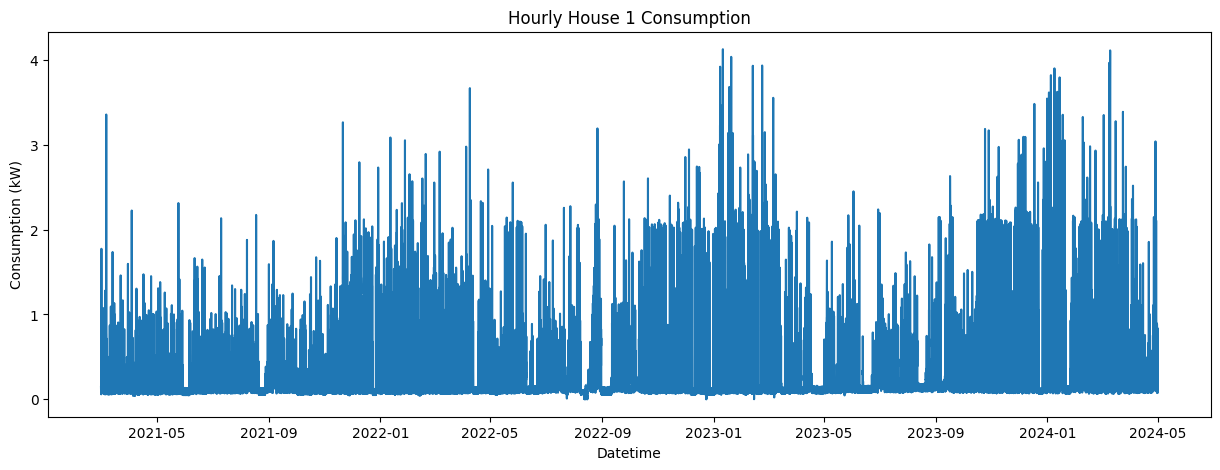

In [ ]:
df = pd.read_csv(file_path)

print("Original shape:", df.shape)
display(df.head())

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Hour"])
df = df.sort_values("datetime").reset_index(drop=True)

data = df[["datetime", "Consumption (kW)"]].copy()
data.rename(columns={"Consumption (kW)": "consumption"}, inplace=True)

print("\nMissing values before cleaning:")
print(data.isnull().sum())

data = data.groupby("datetime", as_index=False)["consumption"].mean()

full_time = pd.date_range(
    start=data["datetime"].min(),
    end=data["datetime"].max(),
    freq="15min"
)

data = data.set_index("datetime").reindex(full_time)
data.index.name = "datetime"

data["consumption"] = data["consumption"].interpolate(method="time")
data["consumption"] = data["consumption"].ffill().bfill()

data = data.reset_index()

print("\nCleaned 15-min shape:", data.shape)
print(data.isnull().sum())

hourly_data = data.set_index("datetime").resample("1h").mean()
hourly_data = hourly_data.interpolate(method="time")
hourly_data = hourly_data.ffill().bfill()
hourly_data = hourly_data.reset_index()

print("\nHourly shape:", hourly_data.shape)
display(hourly_data.head())

plt.figure(figsize=(15, 5))
plt.plot(hourly_data["datetime"], hourly_data["consumption"])
plt.title("Hourly House 1 Consumption")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.show()

In [ ]:
dfh = hourly_data[["datetime", "consumption"]].copy()
dfh = dfh.sort_values("datetime").reset_index(drop=True)

vals = dfh[["consumption"]].values.astype(np.float32)

n = len(vals)
tr_end = int(n * 0.7)
va_end = int(n * 0.8)

scaler = StandardScaler()
scaler.fit(vals[:tr_end])

vals_s = scaler.transform(vals).astype(np.float32)

train_arr = vals_s[:tr_end]
val_arr = vals_s[tr_end - SEQ_LEN : va_end]
test_arr = vals_s[va_end - SEQ_LEN :]

print("Total hourly points:", n)
print("Train:", train_arr.shape)
print("Val:", val_arr.shape)
print("Test:", test_arr.shape)

print("\nTrain date range:", dfh["datetime"].iloc[0], "to", dfh["datetime"].iloc[tr_end - 1])
print("Val date range:", dfh["datetime"].iloc[tr_end], "to", dfh["datetime"].iloc[va_end - 1])
print("Test date range:", dfh["datetime"].iloc[va_end], "to", dfh["datetime"].iloc[-1])

Total hourly points: 27769
Train: (19438, 1)
Val: (3497, 1)
Test: (6274, 1)

Train date range: 2021-03-01 00:00:00 to 2023-05-19 21:00:00
Val date range: 2023-05-19 22:00:00 to 2023-09-12 14:00:00
Test date range: 2023-09-12 15:00:00 to 2024-05-01 00:00:00


In [ ]:
class ForecastDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len):
        self.arr = arr.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.arr) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        x = self.arr[i : i + self.seq_len]
        y = self.arr[i + self.seq_len : i + self.seq_len + self.pred_len]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y


def make_loaders(pred_len):
    tr_ds = ForecastDataset(train_arr, SEQ_LEN, pred_len)
    va_ds = ForecastDataset(val_arr, SEQ_LEN, pred_len)
    te_ds = ForecastDataset(test_arr, SEQ_LEN, pred_len)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    print(f"\n{pred_len}h forecast")
    print("Train samples:", len(tr_ds))
    print("Val samples:", len(va_ds))
    print("Test samples:", len(te_ds))

    return tr_loader, va_loader, te_loader

In [ ]:
# Reference: TimeBase core from the TimeBase paper.
# Purpose: split the 720-hour input into 24-hour daily segments, learn compact basis components,
# and produce the base forecast before any PMFormer residual correction is added.
class TimeBaseCore(nn.Module):
    def __init__(self, seq_len, pred_len, seg_len=24, basis_num=6):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.seg_len = seg_len
        self.basis_num = basis_num

        self.n_seg = math.ceil(seq_len / seg_len)
        self.n_pred_seg = math.ceil(pred_len / seg_len)

        self.basis_extract = nn.Linear(self.n_seg, basis_num)
        self.segment_forecast = nn.Linear(basis_num, self.n_pred_seg)

    def forward(self, x):
        b, t, c = x.shape

        need = self.n_seg * self.seg_len - t

        if need > 0:
            pad = x[:, -1:, :].repeat(1, need, 1)
            x = torch.cat([x, pad], dim=1)

        x = x.permute(0, 2, 1)
        x = x.reshape(b, c, self.n_seg, self.seg_len)

        x = x.permute(0, 1, 3, 2)

        basis = self.basis_extract(x)

        basis = basis.permute(0, 1, 3, 2)

        z = basis.permute(0, 1, 3, 2)

        out = self.segment_forecast(z)

        out = out.permute(0, 1, 3, 2)
        out = out.reshape(b, c, self.n_pred_seg * self.seg_len)

        out = out[:, :, :self.pred_len]
        out = out.permute(0, 2, 1)

        return out, basis


# Reference baseline: TimeBase-only model.
# Purpose: train the TimeBase core alone so the hybrid TimeBase+PMFormer improvement can be measured clearly.
class BaseTimeBase(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.timebase = TimeBaseCore(
            seq_len=seq_len,
            pred_len=pred_len,
            seg_len=TB_P,
            basis_num=TB_R
        )

    def forward(self, x):
        y, basis = self.timebase(x)
        return y, basis, None


# Reference: TimeBase orthogonality regularization.
# Purpose: encourage learned basis components to be different from each other, reducing redundant temporal patterns.
def orth_loss(basis):
    b, c, r, p = basis.shape

    z = basis.reshape(b * c, r, p)

    z = z / (torch.norm(z, dim=-1, keepdim=True) + 1e-8)

    g = torch.matmul(z, z.transpose(1, 2))

    diag = torch.diag_embed(torch.diagonal(g, dim1=1, dim2=2))

    off_diag = g - diag

    return torch.mean(off_diag ** 2)


In [ ]:
# Reference: PMFormer-style patch attention mechanism.
# Purpose: model temporal dependencies through patch-level attention before producing residual corrections.
class ProbPatchSamplingAttention(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        patch_size=16,
        num_patches=4,
        prune_rate=0.30,
        dropout=0.1
    ):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.patch_size = patch_size
        self.num_patches = num_patches
        self.prune_rate = prune_rate

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        b, l, d = x.shape

        x = x.view(b, l, self.n_heads, self.d_head)
        x = x.transpose(1, 2)

        return x

    def forward(self, x, mask=None):
        b, l, d = x.shape

        q = self.split_heads(self.q_proj(x))
        k = self.split_heads(self.k_proj(x))
        v = self.split_heads(self.v_proj(x))

        raw_scores = torch.matmul(q, k.transpose(-2, -1))
        raw_scores = raw_scores / math.sqrt(self.d_head)

        valid = torch.eye(l, l, device=x.device, dtype=torch.bool)

        patch_size = min(self.patch_size, l)

        if patch_size > 1:
            max_start = max(0, l - patch_size)

            for _ in range(self.num_patches):
                if max_start == 0:
                    start = 0
                else:
                    start = torch.randint(
                        low=0,
                        high=max_start + 1,
                        size=(1,),
                        device=x.device
                    ).item()

                end = start + patch_size
                valid[start:end, start:end] = True

        valid = valid.view(1, 1, l, l)

        valid_abs = raw_scores.abs().masked_fill(~valid, -1e9)

        keep_each = max(1, int(patch_size * (1.0 - self.prune_rate)))
        keep_each = min(keep_each, l)

        top_values = torch.topk(
            valid_abs,
            k=keep_each,
            dim=-1
        ).values[..., -1:]

        keep = (valid_abs >= top_values) & valid

        scores = raw_scores.masked_fill(~keep, -1e9)

        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous()
        out = out.view(b, l, d)

        out = self.out_proj(out)

        return out


class MultiScaleSparseAttention(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        factor=2.0,
        dropout=0.1
    ):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.factor = factor

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        b, l, d = x.shape

        x = x.view(b, l, self.n_heads, self.d_head)
        x = x.transpose(1, 2)

        return x

    def forward(self, q_in, k_in, v_in, mask=None):
        b, l, _ = q_in.shape

        q = self.split_heads(self.q_proj(q_in))
        k = self.split_heads(self.k_proj(k_in))
        v = self.split_heads(self.v_proj(v_in))

        scores = torch.matmul(q, k.transpose(-2, -1))
        scores = scores / math.sqrt(self.d_head)

        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)

        dense_scores = torch.softmax(scores, dim=-1)

        routing_scores = dense_scores.pow(self.factor)

        combined_scores = (routing_scores + dense_scores) / 2.0

        sparse_scores = combined_scores / (
            combined_scores.sum(dim=-1, keepdim=True) + 1e-8
        )

        sparse_scores = self.dropout(sparse_scores)

        out = torch.matmul(sparse_scores, v)

        out = out.transpose(1, 2).contiguous()
        out = out.view(b, l, self.d_model)

        out = self.out_proj(out)

        return out


class DilatedCausalPooling(nn.Module):
    def __init__(
        self,
        d_model,
        kernel_size=3,
        dilation=2,
        dropout=0.1
    ):
        super().__init__()

        self.left_pad = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            d_model,
            d_model,
            kernel_size=kernel_size,
            dilation=dilation
        )

        self.bn = nn.BatchNorm1d(d_model)
        self.act = nn.ELU()

        self.pool = nn.MaxPool1d(
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        z = x.transpose(1, 2)

        z = F.pad(z, (self.left_pad, 0))

        z = self.conv(z)
        z = self.bn(z)
        z = self.act(z)
        z = self.pool(z)

        z = z[:, :, :x.size(1)]

        z = z.transpose(1, 2)
        z = self.dropout(z)

        return z


class PMformerEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout,
        patch_size,
        num_patches,
        prune_rate,
        dilation
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.ppsa = ProbPatchSamplingAttention(
            d_model=d_model,
            n_heads=n_heads,
            patch_size=patch_size,
            num_patches=num_patches,
            prune_rate=prune_rate,
            dropout=dropout
        )

        self.causal_pool = DilatedCausalPooling(
            d_model=d_model,
            kernel_size=3,
            dilation=dilation,
            dropout=dropout
        )

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.ppsa(self.norm1(x)))

        x = x + self.dropout(self.causal_pool(self.norm2(x)))

        x = x + self.dropout(self.ff(self.norm3(x)))

        return x


class PMformerDecoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout,
        patch_size,
        num_patches,
        prune_rate,
        factor
    ):
        super().__init__()

        self.norm0 = nn.LayerNorm(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.self_ppsa = ProbPatchSamplingAttention(
            d_model=d_model,
            n_heads=n_heads,
            patch_size=patch_size,
            num_patches=num_patches,
            prune_rate=prune_rate,
            dropout=dropout
        )

        self.cross_mssa = MultiScaleSparseAttention(
            d_model=d_model,
            n_heads=n_heads,
            factor=factor,
            dropout=dropout
        )

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory):
        x = x + self.dropout(self.mlp(self.norm0(x)))

        x = x + self.dropout(self.self_ppsa(self.norm1(x)))

        x = x + self.dropout(
            self.cross_mssa(
                self.norm2(x),
                memory,
                memory
            )
        )

        x = x + self.dropout(self.ff(self.norm3(x)))

        return x


In [ ]:
# Reference: PMFormer residual branch.
# Purpose: learn patch-based temporal corrections and add them to the TimeBase forecast through gated fusion.
class PMformerResidual(nn.Module):
    def __init__(
        self,
        pred_len,
        recent_len=48,
        d_model=32,
        n_heads=4,
        d_ff=64,
        dropout=0.1,
        e_layers=1,
        d_layers=1,
        patch_size=16,
        num_patches=4,
        prune_rate=0.30,
        factor=2.0
    ):
        super().__init__()

        self.pred_len = pred_len
        self.recent_len = recent_len
        self.d_model = d_model

        self.value_proj = nn.Linear(1, d_model)

        self.enc_pos = nn.Parameter(
            torch.zeros(1, recent_len, d_model)
        )

        self.dec_pos = nn.Parameter(
            torch.zeros(1, pred_len, d_model)
        )

        self.encoder_layers = nn.ModuleList([
            PMformerEncoderLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout,
                patch_size=patch_size,
                num_patches=num_patches,
                prune_rate=prune_rate,
                dilation=2 + i
            )
            for i in range(e_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            PMformerDecoderLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout,
                patch_size=min(patch_size, pred_len),
                num_patches=num_patches,
                prune_rate=prune_rate,
                factor=factor
            )
            for _ in range(d_layers)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        recent = x[:, -self.recent_len:, :]

        memory = self.value_proj(recent)
        memory = memory + self.enc_pos

        for layer in self.encoder_layers:
            memory = layer(memory)

        last_token = self.value_proj(recent[:, -1:, :])
        decoder_input = last_token.repeat(1, self.pred_len, 1)
        decoder_input = decoder_input + self.dec_pos

        z = decoder_input

        for layer in self.decoder_layers:
            z = layer(z, memory)

        residual = self.head(z)

        return residual


class TimeBasePMformer(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.timebase = TimeBaseCore(
            seq_len=seq_len,
            pred_len=pred_len,
            seg_len=TB_P,
            basis_num=TB_R
        )

        self.pmformer = PMformerResidual(
            pred_len=pred_len,
            recent_len=RECENT_LEN,
            d_model=D_MODEL,
            n_heads=N_HEADS,
            d_ff=D_FF,
            dropout=DROPOUT,
            e_layers=1,
            d_layers=1,
            patch_size=PPSA_PATCH_SIZE,
            num_patches=PPSA_NUM_PATCHES,
            prune_rate=PPSA_PRUNE_RATE,
            factor=MSSA_FACTOR
        )

        self.gate = nn.Parameter(torch.tensor(-2.0))

    def forward(self, x):
        base_pred, basis = self.timebase(x)

        residual = self.pmformer(x)

        gate_value = torch.sigmoid(self.gate)

        final_pred = base_pred + gate_value * residual

        return final_pred, basis, gate_value


In [ ]:
@torch.no_grad()
# Evaluation reference: compute forecasting metrics on inverse-scaled predictions.
# Purpose: keep MSE, MAE, RMSE, MAPE, MSLE, and R2 comparable across TimeBase and TimeBase+PMFormer.
def evaluate_model(model, loader):
    model.eval()

    preds = []
    trues = []

    for x, y in loader:
        x = x.to(device)

        pred, basis, gate = model(x)

        preds.append(pred.cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    preds_real = scaler.inverse_transform(
        preds.reshape(-1, 1)
    ).reshape(preds.shape)

    trues_real = scaler.inverse_transform(
        trues.reshape(-1, 1)
    ).reshape(trues.shape)

    mae = mean_absolute_error(
        trues_real.reshape(-1),
        preds_real.reshape(-1)
    )

    mse = mean_squared_error(
        trues_real.reshape(-1),
        preds_real.reshape(-1)
    )

    rmse = np.sqrt(mse)

    return mae, mse, rmse, preds_real, trues_real


# Training reference: shared experiment loop for TimeBase and TimeBase+PMFormer.
# Purpose: keep horizons, losses, validation tracking, and metric reporting consistent across model variants.
def train_model(model_name, model, pred_len, lr):
    print("\n" + "=" * 70)
    print(f"Training {model_name} for {pred_len} hour forecast")
    print("=" * 70)

    tr_loader, va_loader, te_loader = make_loaders(pred_len)

    model = model.to(device)

    params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("Trainable parameters:", params)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []

    for epoch in range(1, EPOCHS + 1):
        model.train()

        train_loss = 0.0

        for x, y in tr_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred, basis, gate = model(x)

            pred_loss = criterion(pred, y)

            o_loss = orth_loss(basis)

            loss = pred_loss + TB_LAMBDA_ORTH * o_loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss = train_loss / len(tr_loader.dataset)

        model.eval()

        val_loss = 0.0

        with torch.no_grad():
            for x, y in va_loader:
                x = x.to(device)
                y = y.to(device)

                pred, basis, gate = model(x)

                pred_loss = criterion(pred, y)

                o_loss = orth_loss(basis)

                loss = pred_loss + TB_LAMBDA_ORTH * o_loss

                val_loss += loss.item() * x.size(0)

        val_loss = val_loss / len(va_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if gate is not None:
            print(
                f"Epoch [{epoch}/{EPOCHS}] "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"Gate: {gate.item():.4f}"
            )
        else:
            print(
                f"Epoch [{epoch}/{EPOCHS}] "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f}"
            )

    mae, mse, rmse, preds_real, trues_real = evaluate_model(
        model,
        te_loader
    )

    print(f"\nFinal Test Result: {model_name} | {pred_len} hour forecast")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)

    return {
        "Model": model_name,
        "Horizon": pred_len,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Params": params,
        "Train Losses": train_losses,
        "Val Losses": val_losses,
        "Preds": preds_real,
        "Trues": trues_real
    }


In [ ]:
all_results = []

for h in HORIZONS:
    base_model = BaseTimeBase(
        seq_len=SEQ_LEN,
        pred_len=h
    )

    base_out = train_model(
        model_name="TimeBase",
        model=base_model,
        pred_len=h,
        lr=TIMEBASE_LR
    )

    all_results.append(base_out)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    pm_model = TimeBasePMformer(
        seq_len=SEQ_LEN,
        pred_len=h
    )

    pm_out = train_model(
        model_name="TimeBase+PMFormer",
        model=pm_model,
        pred_len=h,
        lr=PMFORMER_LR
    )

    all_results.append(pm_out)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Training TimeBase for 1 hour forecast

1h forecast
Train samples: 18718
Val samples: 2777
Test samples: 5554
Trainable parameters: 193
Epoch [1/10] Train Loss: 0.744126 | Val Loss: 0.300318
Epoch [2/10] Train Loss: 0.721922 | Val Loss: 0.294617
Epoch [3/10] Train Loss: 0.718924 | Val Loss: 0.302525
Epoch [4/10] Train Loss: 0.715975 | Val Loss: 0.297836
Epoch [5/10] Train Loss: 0.714683 | Val Loss: 0.288231
Epoch [6/10] Train Loss: 0.713879 | Val Loss: 0.292021
Epoch [7/10] Train Loss: 0.713237 | Val Loss: 0.295253
Epoch [8/10] Train Loss: 0.714278 | Val Loss: 0.299664
Epoch [9/10] Train Loss: 0.712224 | Val Loss: 0.296380
Epoch [10/10] Train Loss: 0.712339 | Val Loss: 0.303000

Final Test Result: TimeBase | 1 hour forecast
MAE: 0.38186073303222656
MSE: 0.3116205930709839
RMSE: 0.5582298747567922

Training TimeBase+PMFormer for 1 hour forecast

1h forecast
Train samples: 18718
Val samples: 2777
Test samples: 5554
Trainable parameters: 30787
Epoch [1/10] Train Loss: 0.591197 | Val Loss:

In [ ]:
result_df = pd.DataFrame([
    {
        "Model": x["Model"],
        "Horizon": x["Horizon"],
        "MAE": x["MAE"],
        "MSE": x["MSE"],
        "RMSE": x["RMSE"],
        "Params": x["Params"]
    }
    for x in all_results
])

result_df = result_df.sort_values(
    ["Model", "Horizon"]
).reset_index(drop=True)

display(result_df)

,Model,Horizon,MAE,MSE,RMSE,Params
0,TimeBase,1,0.381861,0.311621,0.558230,193
1,TimeBase,8,0.375078,0.317459,0.563435,193
2,TimeBase,16,0.373234,0.311788,0.558380,193
3,TimeBase,24,0.380174,0.313523,0.559931,193
4,TimeBase+PMFormer,1,0.280138,0.188603,0.434284,30787
5,TimeBase+PMFormer,8,0.355017,0.279467,0.528647,31011
6,TimeBase+PMFormer,16,0.368597,0.303354,0.550776,31267
7,TimeBase+PMFormer,24,0.382785,0.309119,0.555985,31523


In [ ]:
rows = []

for model_name in ["TimeBase", "TimeBase+PMFormer"]:
    row = {
        "Load House 1": model_name
    }

    temp = result_df[result_df["Model"] == model_name]

    for h in HORIZONS:
        one = temp[temp["Horizon"] == h].iloc[0]

        if h == 1:
            mse_col = "MSE 1 Hour"
            mae_col = "MAE 1 Hour"
        else:
            mse_col = f"MSE {h} hour"
            mae_col = f"MAE {h} hour"

        row[mse_col] = one["MSE"]
        row[mae_col] = one["MAE"]

    row["Parameters"] = int(temp["Params"].iloc[-1])

    rows.append(row)

faculty_table = pd.DataFrame(rows)

display(faculty_table)

faculty_table.to_csv(
    "TimeBase_PMFormer_Load_House_1_results.csv",
    index=False
)

print("Saved CSV: TimeBase_PMFormer_Load_House_1_results.csv")

,Load House 1,MSE 1 Hour,MAE 1 Hour,MSE 8 hour,MAE 8 hour,MSE 16 hour,MAE 16 hour,MSE 24 hour,MAE 24 hour,Parameters
0,TimeBase,0.311621,0.381861,0.317459,0.375078,0.311788,0.373234,0.313523,0.380174,193
1,TimeBase+PMFormer,0.188603,0.280138,0.279467,0.355017,0.303354,0.368597,0.309119,0.382785,31523


Saved CSV: TimeBase_PMFormer_Load_House_1_results.csv


In [ ]:
base_df = result_df[result_df["Model"] == "TimeBase"].copy()
pm_df = result_df[result_df["Model"] == "TimeBase+PMFormer"].copy()

compare_df = base_df.merge(
    pm_df,
    on="Horizon",
    suffixes=("_TimeBase", "_PMFormer")
)

compare_df["MAE_Improvement"] = (
    compare_df["MAE_TimeBase"] - compare_df["MAE_PMFormer"]
)

compare_df["MSE_Improvement"] = (
    compare_df["MSE_TimeBase"] - compare_df["MSE_PMFormer"]
)

compare_df["MAE_Improvement_%"] = (
    compare_df["MAE_Improvement"] / compare_df["MAE_TimeBase"]
) * 100

compare_df["MSE_Improvement_%"] = (
    compare_df["MSE_Improvement"] / compare_df["MSE_TimeBase"]
) * 100

display(compare_df)

,Model_TimeBase,Horizon,MAE_TimeBase,MSE_TimeBase,RMSE_TimeBase,Params_TimeBase,Model_PMFormer,MAE_PMFormer,MSE_PMFormer,RMSE_PMFormer,Params_PMFormer,MAE_Improvement,MSE_Improvement,MAE_Improvement_%,MSE_Improvement_%
0,TimeBase,1,0.381861,0.311621,0.558230,193,TimeBase+PMFormer,0.280138,0.188603,0.434284,30787,0.101723,0.123018,26.638727,39.476726
1,TimeBase,8,0.375078,0.317459,0.563435,193,TimeBase+PMFormer,0.355017,0.279467,0.528647,31011,0.020061,0.037991,5.348533,11.967346
2,TimeBase,16,0.373234,0.311788,0.558380,193,TimeBase+PMFormer,0.368597,0.303354,0.550776,31267,0.004637,0.008434,1.242314,2.704958
3,TimeBase,24,0.380174,0.313523,0.559931,193,TimeBase+PMFormer,0.382785,0.309119,0.555985,31523,-0.002611,0.004404,-0.686817,1.404788


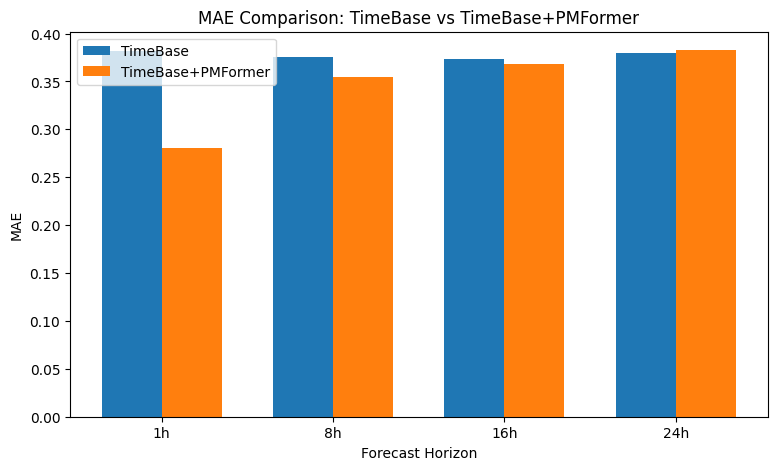

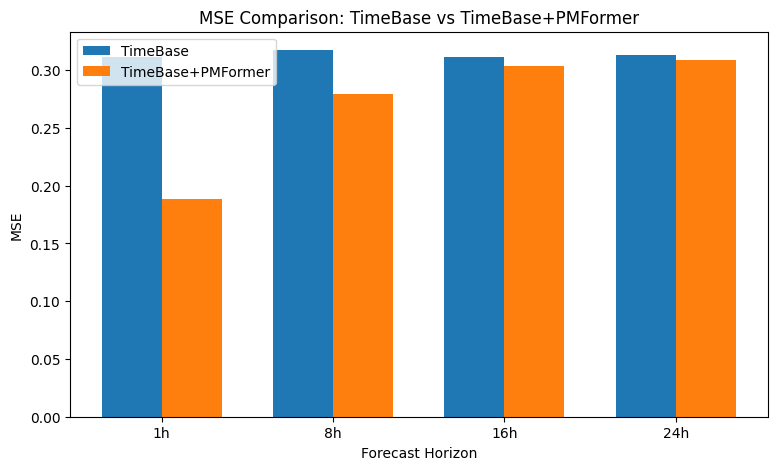

In [ ]:
mae_pivot = result_df.pivot(
    index="Horizon",
    columns="Model",
    values="MAE"
)

x = np.arange(len(HORIZONS))
w = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - w / 2,
    mae_pivot["TimeBase"],
    width=w,
    label="TimeBase"
)

plt.bar(
    x + w / 2,
    mae_pivot["TimeBase+PMFormer"],
    width=w,
    label="TimeBase+PMFormer"
)

plt.xticks(x, [f"{h}h" for h in HORIZONS])
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("MAE Comparison: TimeBase vs TimeBase+PMFormer")
plt.legend()
plt.show()


mse_pivot = result_df.pivot(
    index="Horizon",
    columns="Model",
    values="MSE"
)

plt.figure(figsize=(9, 5))

plt.bar(
    x - w / 2,
    mse_pivot["TimeBase"],
    width=w,
    label="TimeBase"
)

plt.bar(
    x + w / 2,
    mse_pivot["TimeBase+PMFormer"],
    width=w,
    label="TimeBase+PMFormer"
)

plt.xticks(x, [f"{h}h" for h in HORIZONS])
plt.xlabel("Forecast Horizon")
plt.ylabel("MSE")
plt.title("MSE Comparison: TimeBase vs TimeBase+PMFormer")
plt.legend()
plt.show()

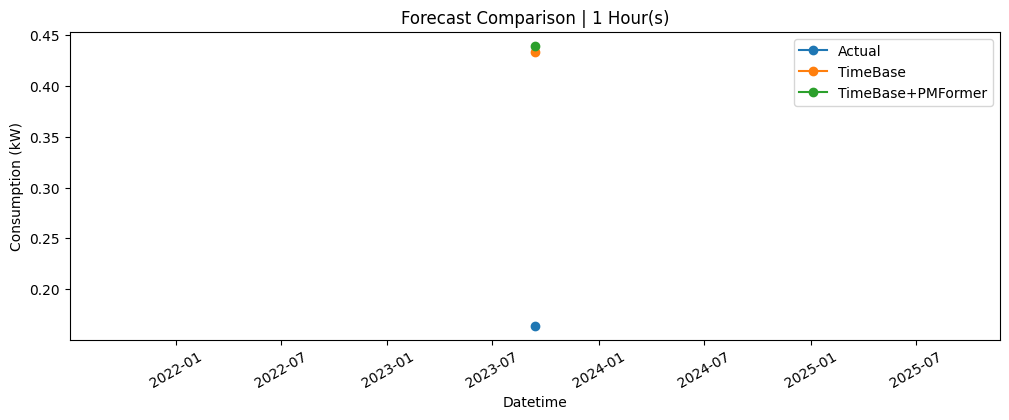

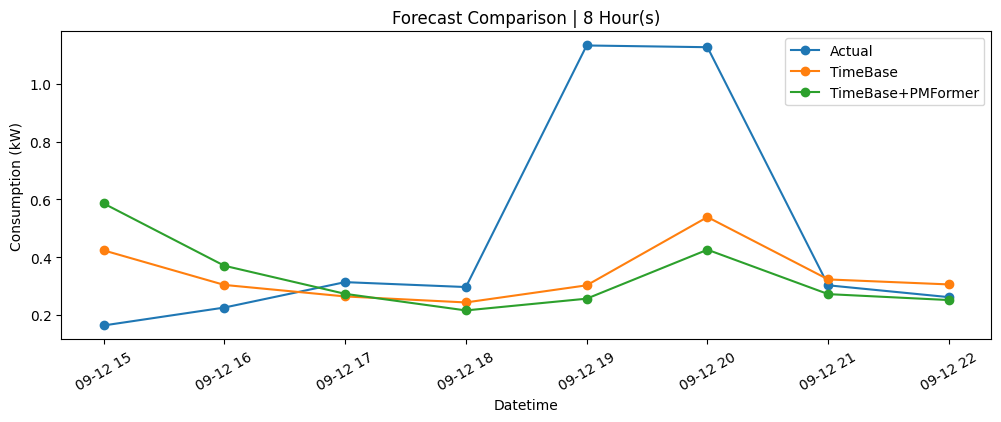

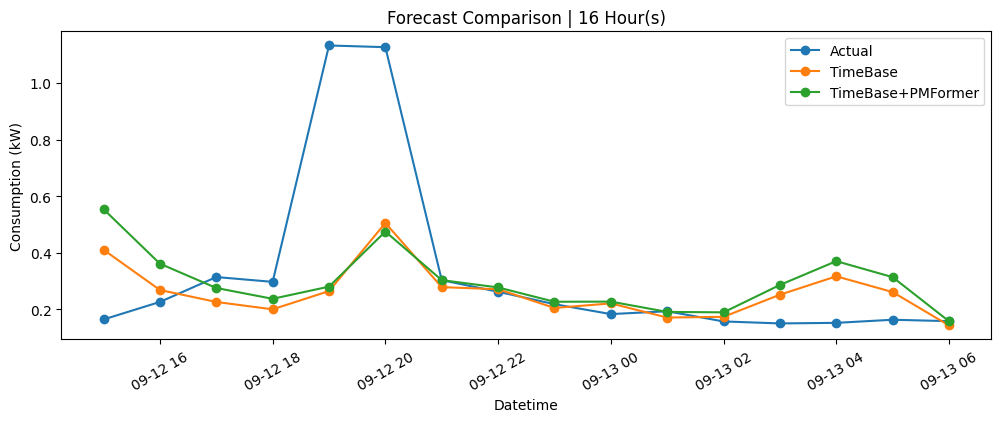

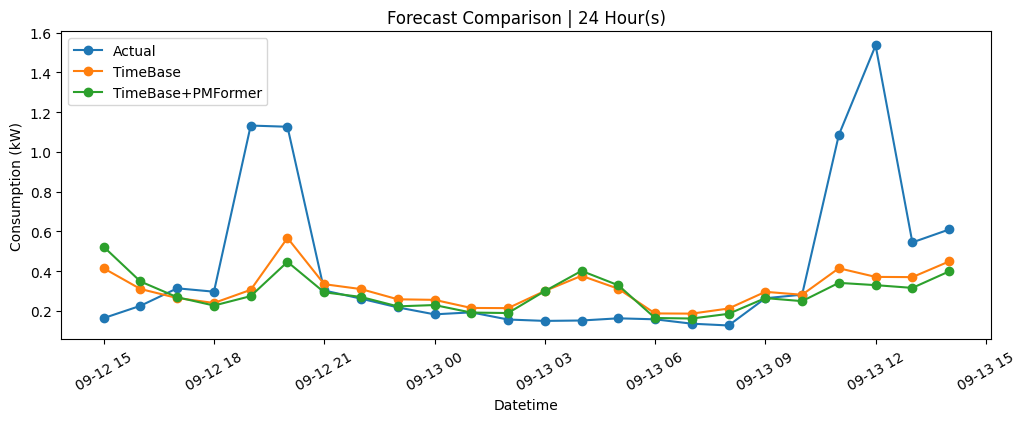

In [ ]:
for h in HORIZONS:
    base_out = None
    pm_out = None

    for x in all_results:
        if x["Horizon"] == h and x["Model"] == "TimeBase":
            base_out = x

        if x["Horizon"] == h and x["Model"] == "TimeBase+PMFormer":
            pm_out = x

    actual = base_out["Trues"][0, :, 0]
    base_pred = base_out["Preds"][0, :, 0]
    pm_pred = pm_out["Preds"][0, :, 0]

    future_time = dfh["datetime"].iloc[va_end : va_end + h]

    plt.figure(figsize=(12, 4))

    plt.plot(
        future_time,
        actual,
        marker="o",
        label="Actual"
    )

    plt.plot(
        future_time,
        base_pred,
        marker="o",
        label="TimeBase"
    )

    plt.plot(
        future_time,
        pm_pred,
        marker="o",
        label="TimeBase+PMFormer"
    )

    plt.title(f"Forecast Comparison | {h} Hour(s)")
    plt.xlabel("Datetime")
    plt.ylabel("Consumption (kW)")
    plt.legend()
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
def count_model_variables(model, show_layers=True):
    rows = []

    total_vars = 0
    trainable_vars = 0
    non_trainable_vars = 0

    for name, param in model.named_parameters():
        n = param.numel()

        total_vars += n

        if param.requires_grad:
            trainable_vars += n
        else:
            non_trainable_vars += n

        rows.append({
            "Layer": name,
            "Shape": list(param.shape),
            "Trainable": param.requires_grad,
            "Variables": n
        })

    layer_df = pd.DataFrame(rows)

    print("Total Variables:", total_vars)
    print("Trainable Variables:", trainable_vars)
    print("Non-Trainable Variables:", non_trainable_vars)

    if show_layers:
        display(layer_df)

    return layer_df


print("Base TimeBase parameter count for 24h:")
temp_base = BaseTimeBase(
    seq_len=SEQ_LEN,
    pred_len=24
).to(device)

base_layers = count_model_variables(
    temp_base,
    show_layers=True
)


print("\nTimeBase+PMFormer parameter count for 24h:")
temp_pm = TimeBasePMformer(
    seq_len=SEQ_LEN,
    pred_len=24
).to(device)

pm_layers = count_model_variables(
    temp_pm,
    show_layers=True
)

Base TimeBase parameter count for 24h:
Total Variables: 193
Trainable Variables: 193
Non-Trainable Variables: 0


,Layer,Shape,Trainable,Variables
0,timebase.basis_extract.weight,"[6, 30]",True,180
1,timebase.basis_extract.bias,[6],True,6
2,timebase.segment_forecast.weight,"[1, 6]",True,6
3,timebase.segment_forecast.bias,[1],True,1



TimeBase+PMFormer parameter count for 24h:
Total Variables: 31523
Trainable Variables: 31523
Non-Trainable Variables: 0


,Layer,Shape,Trainable,Variables
0,gate,[],True,1
1,timebase.basis_extract.weight,"[6, 30]",True,180
2,timebase.basis_extract.bias,[6],True,6
3,timebase.segment_forecast.weight,"[1, 6]",True,6
4,timebase.segment_forecast.bias,[1],True,1
...,...,...,...,...
62,pmformer.decoder_layers.0.ff.3.bias,[32],True,32
63,pmformer.head.0.weight,[32],True,32
64,pmformer.head.0.bias,[32],True,32
65,pmformer.head.1.weight,"[1, 32]",True,32


In [ ]:
pmformer_epoch_rows = []

for res in all_results:
    if res["Model"] == "TimeBase+PMFormer":
        h = res["Horizon"]

        train_losses = res["Train Losses"]
        val_losses = res["Val Losses"]

        for ep in range(1, len(train_losses) + 1):
            tr = train_losses[ep - 1]
            va = val_losses[ep - 1]

            pmformer_epoch_rows.append({
                "Model": "TimeBase+PMFormer",
                "Horizon": f"{h} Hour",
                "Epoch": ep,
                "Learning Rate": PMFORMER_LR,
                "Train Loss": tr,
                "Val Loss": va,
                "Val - Train Gap": va - tr
            })

pmformer_lr_table = pd.DataFrame(pmformer_epoch_rows)

display(pmformer_lr_table)

,Model,Horizon,Epoch,Learning Rate,Train Loss,Val Loss,Val - Train Gap
0,TimeBase+PMFormer,1 Hour,1,0.001,0.591197,0.233305,-0.357891
1,TimeBase+PMFormer,1 Hour,2,0.001,0.486443,0.233179,-0.253264
2,TimeBase+PMFormer,1 Hour,3,0.001,0.472797,0.223462,-0.249335
3,TimeBase+PMFormer,1 Hour,4,0.001,0.463193,0.238740,-0.224453
4,TimeBase+PMFormer,1 Hour,5,0.001,0.454806,0.226303,-0.228503
5,TimeBase+PMFormer,1 Hour,6,0.001,0.448655,0.226634,-0.222021
6,TimeBase+PMFormer,1 Hour,7,0.001,0.441205,0.231122,-0.210083
7,TimeBase+PMFormer,1 Hour,8,0.001,0.432232,0.230793,-0.201439
8,TimeBase+PMFormer,1 Hour,9,0.001,0.430892,0.233490,-0.197402
9,TimeBase+PMFormer,1 Hour,10,0.001,0.428020,0.226214,-0.201806


In [ ]:
best_epoch_rows = []

for h in HORIZONS:
    temp = pmformer_lr_table[
        pmformer_lr_table["Horizon"] == f"{h} Hour"
    ].copy()

    best_row = temp.loc[temp["Val Loss"].idxmin()]

    best_epoch_rows.append({
        "Horizon": f"{h} Hour",
        "Best Epoch": int(best_row["Epoch"]),
        "Best Val Loss": best_row["Val Loss"],
        "Train Loss at Best Epoch": best_row["Train Loss"],
        "Learning Rate": best_row["Learning Rate"],
        "Gap": best_row["Val - Train Gap"]
    })

best_epoch_df = pd.DataFrame(best_epoch_rows)

display(best_epoch_df)

,Horizon,Best Epoch,Best Val Loss,Train Loss at Best Epoch,Learning Rate,Gap
0,1 Hour,3,0.223462,0.472797,0.001,-0.249335
1,8 Hour,9,0.276740,0.628683,0.001,-0.351943
2,16 Hour,9,0.280887,0.644093,0.001,-0.363205
3,24 Hour,10,0.285395,0.659685,0.001,-0.374290


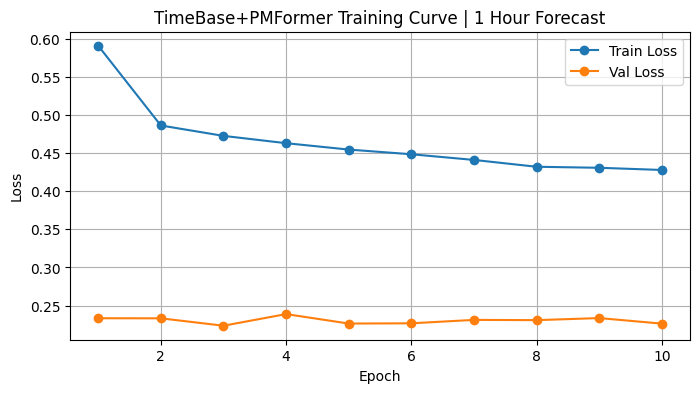

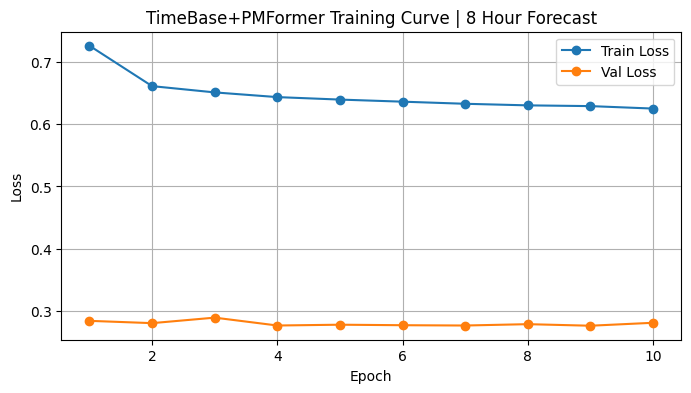

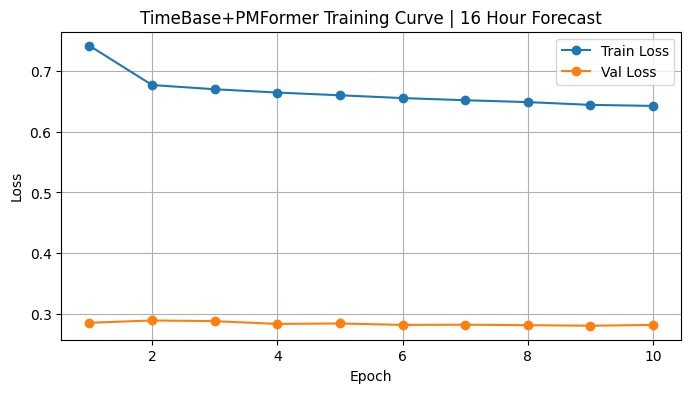

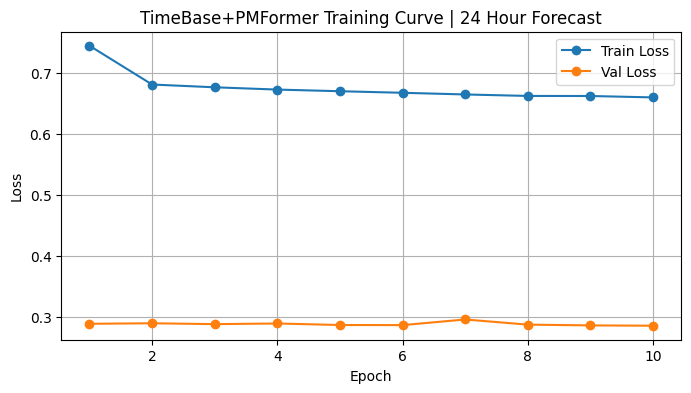

In [ ]:
for h in HORIZONS:
    temp = pmformer_lr_table[
        pmformer_lr_table["Horizon"] == f"{h} Hour"
    ]

    plt.figure(figsize=(8, 4))

    plt.plot(
        temp["Epoch"],
        temp["Train Loss"],
        marker="o",
        label="Train Loss"
    )

    plt.plot(
        temp["Epoch"],
        temp["Val Loss"],
        marker="o",
        label="Val Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"TimeBase+PMFormer Training Curve | {h} Hour Forecast")
    plt.legend()
    plt.grid(True)
    plt.show()

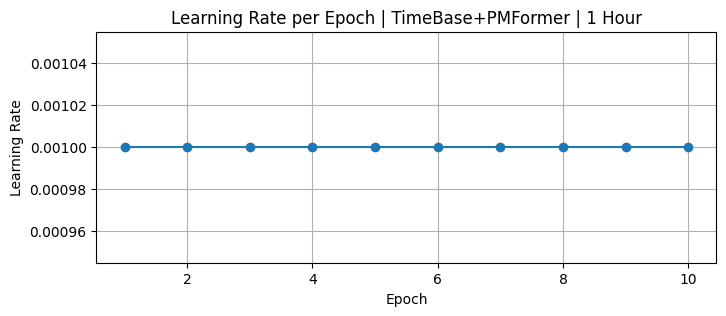

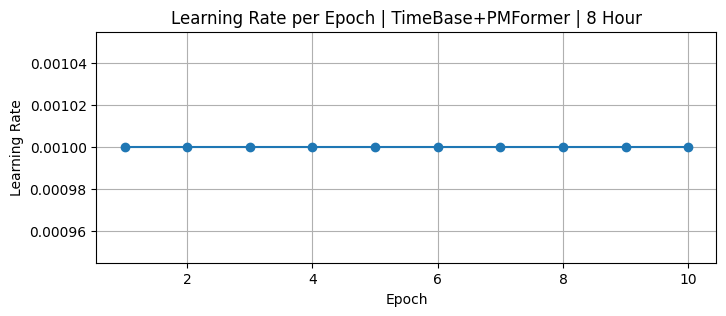

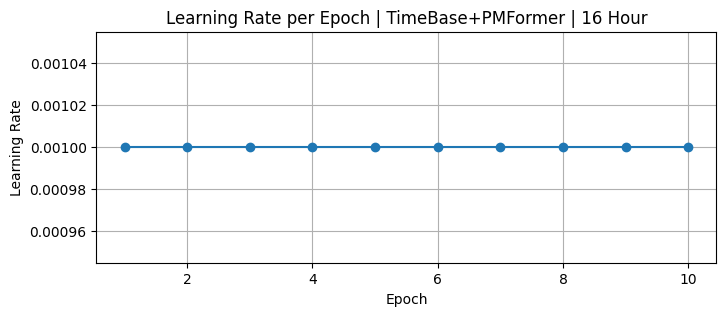

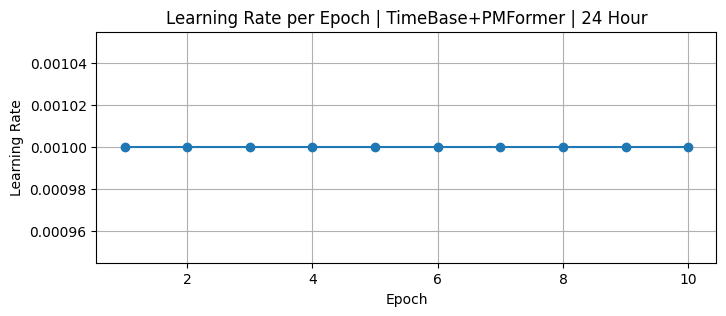

In [ ]:
for h in HORIZONS:
    temp = pmformer_lr_table[
        pmformer_lr_table["Horizon"] == f"{h} Hour"
    ]

    plt.figure(figsize=(8, 3))

    plt.plot(
        temp["Epoch"],
        temp["Learning Rate"],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(f"Learning Rate per Epoch | TimeBase+PMFormer | {h} Hour")
    plt.grid(True)
    plt.show()

In [ ]:
overfit_rows = []

for h in HORIZONS:
    temp = pmformer_lr_table[
        pmformer_lr_table["Horizon"] == f"{h} Hour"
    ].reset_index(drop=True)

    best_val = temp["Val Loss"].min()
    best_epoch = int(temp.loc[temp["Val Loss"].idxmin(), "Epoch"])

    last_train = temp["Train Loss"].iloc[-1]
    last_val = temp["Val Loss"].iloc[-1]

    if last_val > best_val and last_train < temp["Train Loss"].iloc[best_epoch - 1]:
        status = "Possible overfitting after best epoch"
    elif last_val <= best_val * 1.02:
        status = "Still safe to extend epochs"
    else:
        status = "Watch carefully"

    overfit_rows.append({
        "Horizon": f"{h} Hour",
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val,
        "Last Train Loss": last_train,
        "Last Val Loss": last_val,
        "Status": status
    })

overfit_df = pd.DataFrame(overfit_rows)

display(overfit_df)